In [ ]:
!pip install xgboost
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.3 MB/s eta 0:00:00


In [ ]:
from typing import Tuple

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from scipy.optimize import curve_fit
from xgboost import XGBRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [ ]:
df_full = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/MPP/df_full.parquet')
df_full = df_full.rename(columns={'power_cell_mwcm2': 'mpp_mwcm2', 'local_irradiance_mwcm2':'G_mwcm2', 'irradiance_30_degrees_mwcm2':'cams_mwcm2'})

df_3 = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Features/df_features.parquet')
df_3 = df_3.rename(columns={'power_cell_mwcm2': 'mpp_mwcm2', 'local_irradiance_mwcm2':'G_mwcm2', 'irradiance_30_degrees_mwcm2':'cams_mwcm2'})

In [ ]:
df_full.columns

Index(['time', 'index', 'cell_id', 'mpp_mwcm2', 'G_mwcm2', 'hour_fraction',
       'cams_mwcm2', 'irradiance_30_is_imputed', 'DeviceTemp', 't_chamber',
       'AmbientTemp', 'Humidity', 'power_art', 'local_irradiance_art'],
      dtype='object')

In [ ]:
def plot_profile(df=df_full, target_col='mpp_mwcm2', cell_id=0, min_gci=0, min_G_mwcm2=0, min_power=None,
                 isolated_target_line=True, start_date=None, end_date=None, color=True,
                 temp=False, feature=None, regression_analysis=False, predicted=False,
                 trend=False, df_window=200, Health=False):

    # 1. Exclusivity validation for the right Y-axis
    active_right_axes = sum([temp, (feature is not None), Health])
    if active_right_axes > 1:
        print('[ERROR] Mutually exclusive usage: "temp", "feature", and "Health" cannot be defined simultaneously on the right axis.')
        return

    # 2. Target metadata extraction (using the previously defined dictionary)
    target_full_name = TARGET_TITLES.get(target_col, target_col)

    # Attempt to extract unit if it is in parentheses in the dictionary
    if "(" in target_full_name:
        metric_name = target_full_name.split("(")[0].strip()
        unit = target_full_name.split("(")[1].replace(")", "").strip()
    else:
        metric_name = target_full_name
        unit = "u.a."

    # 3. Safe filtering by cell_id
    cell_df = df[df['cell_id'] == cell_id].copy()
    if cell_df.empty:
        print(f"Error: No data found for cell_id {cell_id}.")
        return

    cell_name = 'M0' if cell_id == 0 else 'P12'

    # 4. Time index preparation
    if 'time' in cell_df.columns:
        cell_df.set_index('time', inplace=True)
    cell_df.index = pd.to_datetime(cell_df.index)
    cell_df.sort_index(inplace=True)

    # 5. Apply Filters (Dynamic adjustment of min_power if it is None)
    # If min_power is not specified, use 5% of the maximum to clean up noise
    if min_power is None:
        min_power = cell_df[target_col].max() * 0.05

    mask_clear = (cell_df['gci'] > min_gci) & \
                 (cell_df['G_mwcm2'] > min_G_mwcm2) & \
                 (cell_df[target_col].notna()) & \
                 (cell_df[target_col] > min_power)

    cell_df_clear = cell_df[mask_clear].copy()

    # 6. Filter by Dates
    if start_date is not None or end_date is not None:
        if start_date:
            cell_df_clear = cell_df_clear[cell_df_clear.index >= pd.to_datetime(start_date)]
        if end_date:
            cell_df_clear = cell_df_clear[cell_df_clear.index <= pd.to_datetime(end_date)]

    if cell_df_clear.empty:
        print(f"Error: No data meets the filter criteria for cell {cell_id}.")
        return

    # =========================================================================
    # DYNAMIC CALCULATIONS
    # =========================================================================
    isolate_col = f"isolate_{target_col}"
    if isolated_target_line and isolate_col not in cell_df_clear.columns:
        cell_df_clear[isolate_col] = cell_df_clear[target_col].rolling(window='4min', min_periods=1, center=False).max()

    if trend and 'Trend' not in cell_df_clear.columns:
        print("Warning: 'Trend' column not found. Cannot plot trend.")
        trend = False

    if Health and 'Health' not in cell_df_clear.columns:
        print("Warning: 'Health' column not found. Cannot plot Health.")
        Health = False

    # Name of the prediction column generated by level_3_xgboost_dynamic
    pred_col = f"{target_col}_pred"

    # =========================================================================
    # PLOT PREPARATION
    # =========================================================================
    days_passed = (cell_df_clear.index - cell_df_clear.index.min()).total_seconds() / (24 * 3600)
    df_plot = cell_df_clear.copy().reset_index()
    idx_x = df_plot.index

    # --- MODE 1: TEMPORAL PLOT (TIME SERIES) ---
    if temp or (feature is not None) or predicted or trend or Health:
        fig, ax1 = plt.subplots(figsize=(20, 8), dpi=150)

        # Original scatter plot
        if color:
            sc = ax1.scatter(idx_x, df_plot[target_col], c=days_passed, cmap='coolwarm', alpha=0.5, s=10, label=f'{metric_name} (Raw)')
            cbar = fig.colorbar(sc, ax=ax1, pad=0.1)
            cbar.set_label('Days since start', rotation=270, labelpad=20, fontsize=14)
        else:
            ax1.scatter(idx_x, df_plot[target_col], alpha=0.5, s=10, label=f'{metric_name} (Raw)')

        ax1.set_ylabel(f'{metric_name} ({unit})', color='black', fontsize=14)

        # Isolated line (Envelope)
        if isolated_target_line:
            sns.lineplot(x=idx_x, y=df_plot[isolate_col], color='red', linewidth=2, label=f'Isolated {metric_name}', ax=ax1)

        # Dynamic Predictions
        if predicted and pred_col in df_plot.columns:
            if 'is_train' in df_plot.columns:
                train_mask = df_plot['is_train']
                val_mask = ~df_plot['is_train']
                if train_mask.any():
                    sns.lineplot(x=idx_x[train_mask], y=df_plot.loc[train_mask, pred_col],
                                 color='green', linewidth=2.5, linestyle='--', label='Pred Train', ax=ax1)
                if val_mask.any():
                    sns.lineplot(x=idx_x[val_mask], y=df_plot.loc[val_mask, pred_col],
                                 color='darkorange', linewidth=2.5, linestyle='--', label='Pred Validation', ax=ax1)
            else:
                sns.lineplot(x=idx_x, y=df_plot[pred_col], color='green', linewidth=2.5, linestyle='--', label='Predicted', ax=ax1)

        # Trend
        if trend:
            sns.lineplot(x=idx_x, y=df_plot['Trend'], color='purple', linewidth=3.5, alpha=0.9, linestyle='-.', label='Irreversible Trend', ax=ax1)

        # Secondary Axis (Twinx)
        if temp or (feature is not None) or Health:
            ax2 = ax1.twinx()
            if temp:
                sns.lineplot(x=idx_x, y=df_plot['DeviceTemp'].rolling(window=df_window, min_periods=1, center=False).mean(),
                             color='tab:orange', linewidth=1.5, ax=ax2, alpha=0.7, linestyle=':', label='Temperature Trend')
                ax2.set_ylabel('Device Temp (°C)', color='tab:orange', fontsize=14)
            elif feature is not None:
                sns.lineplot(x=idx_x, y=df_plot[feature].rolling(window=df_window, min_periods=1, center=False).mean(),
                             linewidth=1.5, ax=ax2, alpha=0.7, color='black', linestyle='-.', label=f'{feature} Trend')
                ax2.set_ylabel(feature, color='black', fontsize=14)
            elif Health:
                health_percent = (df_plot['Health'] / df_plot['Health'].max()) * 100
                sns.lineplot(x=idx_x, y=health_percent, linewidth=3, ax=ax2, alpha=0.9, color='teal', label='Retention (%)')
                ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.6, label='T80 Threshold')
                ax2.set_ylabel('Health / Retention (%)', color='teal', fontsize=14, fontweight='bold')
                ax2.set_ylim(0, 105)

        # X-Axis Format
        num_ticks = min(10, len(df_plot))
        tick_indices = np.linspace(0, len(df_plot) - 1, num_ticks, dtype=int)
        tick_labels = df_plot['time'].iloc[tick_indices].dt.strftime('%m-%d %H:%M')
        ax1.set_xticks(tick_indices)
        ax1.set_xticklabels(tick_labels, rotation=45, ha='right')
        ax1.set_title(f'Temporal Profile: {metric_name} | Cell {cell_name}', fontsize=16, fontweight='bold')
        ax1.grid(True, alpha=0.3)

    # --- MODE 2: HOURLY PLOT (DIURNAL PROFILE) ---
    else:
        idx_horario = cell_df_clear.index.hour + cell_df_clear.index.minute/60 + cell_df_clear.index.second/3600
        fig, ax = plt.subplots(figsize=(16, 9))

        if color:
            sc = ax.scatter(idx_horario, cell_df_clear[target_col], c=days_passed, cmap='coolwarm', alpha=0.5, s=10)
            plt.colorbar(sc, label='Days since start')
        else:
            ax.scatter(idx_horario, cell_df_clear[target_col], alpha=0.5, s=10)

        if isolated_target_line:
            sort_idx = np.argsort(idx_horario)
            sns.lineplot(x=idx_horario[sort_idx], y=cell_df_clear[isolate_col].iloc[sort_idx], color='red', label=f'Isolated {metric_name}', ax=ax)

        ax.set_xlabel('Time of day (Solar)', fontsize=14)
        ax.set_ylabel(f'{metric_name} ({unit})', fontsize=14)
        ax.set_title(f'Diurnal Performance: {metric_name} | Cell {cell_name}', fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
TARGET_TITLES = {
    'mpp_mwcm2': 'MPP ($mW/cm^2$)',
}

def level_3_xgboost_dynamic(df_full, df_day, target_col='mpp_mwcm2', cell_id=0, min_G_mwcm2=0, isolate_target=True, window='4min', train_day_split=15, cross_val=False, plot_diagnostics=True, lags=True, accumulations=[]):

    # Get the friendly name for prints and plots, or use the default column name
    target_name = TARGET_TITLES.get(target_col, target_col)

    print(f"Starting Level 3 for cell_id={cell_id}. Modeling {target_name}...")
    n_splits = 51 - train_day_split

    df_f = df_full.copy()
    df = df_day.copy()

    # Define cell name for plots
    cell_name = 'M0' if cell_id == 0 else 'P12'

    # --- 1. Index Preparation ---
    if 'time' in df_f.columns:
        df_f.set_index('time', inplace=True)
    if 'time' in df.columns:
        df.set_index('time', inplace=True)

    # --- 2. Feature Engineering (24/7 calculations with df_full) ---
    # Isolate the specific cell data and sort chronologically
    df_f_cell = df_f[df_f['cell_id'] == cell_id].sort_index().copy()

    # A. Physical calculation of Absolute Humidity (Magnus-Tetens)
    p_vap = 6.112 * np.exp((17.67 * df_f_cell['AmbientTemp']) / (df_f_cell['AmbientTemp'] + 243.5)) * (df_f_cell['Humidity'] / 100.0)
    df_f_cell['HA_g_m3'] = (216.74 * p_vap) / (df_f_cell['AmbientTemp'] + 273.15)

    # B. Continuous Accumulations (Minute by minute) EXCLUSIVE TO THE CELL
    df_f_cell['G_accum_cont'] = df_f_cell['G_mwcm2'].cumsum()
    df_f_cell['HA_accum_cont_g_m3'] = df_f_cell['HA_g_m3'].cumsum() # Being in df_f_cell, it correctly starts from zero
    df_f_cell['Temp_accum_cont'] = df_f_cell['DeviceTemp'].cumsum()

    # C. Mapping to the daily dataset used by the model (df_day -> df)
    df['G_accum_cont'] = pd.Series(df.index.map(df_f_cell['G_accum_cont']), index=df.index).ffill().fillna(0)
    df['HA_accum_cont_g_m3'] = pd.Series(df.index.map(df_f_cell['HA_accum_cont_g_m3']), index=df.index).ffill().fillna(0)
    df['Temp_accum_cont'] = pd.Series(df.index.map(df_f_cell['Temp_accum_cont']), index=df.index).ffill().fillna(0)

    df['HA_g_m3'] = pd.Series(df.index.map(df_f_cell['HA_g_m3']), index=df.index).ffill().fillna(0)

    # --- 3. Real Target Identification ---
    df['window_group'] = df.index.floor(window)
    # Select the peak of the target_col dynamically
    idx_target = df[df['cell_id'] == cell_id].groupby('window_group')[target_col].idxmax()
    df['is_target_peak'] = False
    df.loc[idx_target, 'is_target_peak'] = True

    # --- 4. Mask Definition & Train/Validation Split ---
    base_mask = (df['cell_id'] == cell_id) & (df['G_mwcm2'] > min_G_mwcm2) & (df[target_col].notna())

    if isolate_target:
        train_pool_mask = base_mask & (df['is_target_peak'] == True)
    else:
        train_pool_mask = base_mask

    if not train_pool_mask.any():
        print(f"Warning: No valid training data found for cell_id {cell_id} and target {target_col}.")
        return df, None, None, None

    start_date = df.loc[train_pool_mask].index.min()
    split_date = start_date + pd.Timedelta(days=train_day_split)

    train_mask = train_pool_mask & (df.index <= split_date)
    valid_mask = train_pool_mask & (df.index > split_date)

    df['is_train'] = df.index <= split_date

    # --- 5. Age Tracking & Visual Health Calculation (Exponential Trend) ---
    time_zero = df_f_cell.index.min()

    # 5.A - Your original clock in integers
    df['days_elapsed_int'] = (df.index - time_zero).days

    # 5.B - NEW CLOCK: Continuous (exact day fractions)
    df['days_elapsed_continuous'] = (df.index - time_zero).total_seconds() / (24 * 3600)

    # --- 6. Model Fitting ---
    # Use the dynamic features passed through accumulations + base variables.
    # (If you want to try lags later, they are added automatically if lags=True)
    features = accumulations if accumulations else ['G_mwcm2', 'DeviceTemp', 'Humidity']

    X_train = df.loc[train_mask, features]
    y_train = df.loc[train_mask, target_col]

    if plot_diagnostics:
        from sklearn.feature_selection import mutual_info_regression
        # Auxiliary function to plot MI if necessary
        pass

    tscv = TimeSeriesSplit(n_splits=5)

    param_dist = {
        'n_estimators': [200, 300, 500],       # Slightly reduced maximum
        'learning_rate': [0.01, 0.03, 0.05],
        'max_depth': [2, 3, 4],                # CRITICAL: Shallow trees generalize better. Removed 5 and 7.
        'subsample': [0.6, 0.75, 0.85],        # Lower subsample forces more randomness (less memorization)
        'colsample_bytree': [0.6, 0.8],        # Removed 1.0. Forces trees to use different features.
        'gamma': [0.5, 1.0, 5.0],              # Aggressive pruning: requires a larger loss reduction to split a branch.
        'min_child_weight': [10, 15, 20],      # CRITICAL: Requires many samples in a leaf. Stops fitting to tiny noise spikes.
        'reg_lambda': [10.0, 50.0, 100.0],     # Massive L2 regularization to shrink overly confident predictions.
        'reg_alpha': [0.5, 1.0, 5.0]           # Added L1 regularization to push useless feature weights to exactly zero.
    }

    xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

    random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=100,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42
    )

    print("\n[INFO] Starting hyperparameter optimization...")
    random_search.fit(X_train, y_train)
    results = random_search.cv_results_
    print("Best params:", random_search.best_params_)
    print("Best score:", random_search.best_score_)
    dynamic_model = random_search.best_estimator_

    # # --- Dynamic Monotonic Constraints Configuration ---
    # # This ensures the model respects physics: G(+) and Temp(-)
    # m_constraints = []
    # for f in features:
    #     if f == 'G_mwcm2': m_constraints.append(1)      # More light, more power
    #     elif f == 'DeviceTemp': m_constraints.append(-1) # More heat, less power
    #     else: m_constraints.append(0)                    # No constraint for the rest

    # # Model definition with fixed parameters (Standalone)
    # dynamic_model = XGBRegressor(
    #     n_estimators=1000,
    #     max_depth=4,
    #     learning_rate=0.01,
    #     objective='reg:squarederror',
    #     tree_method='exact',
    #     reg_lambda=50,
    #     reg_alpha=20,
    #     min_child_weight=15,
    #     monotone_constraints=tuple(m_constraints),
    #     random_state=42
    # )

    # # Model fitting (Correction: y_train is used instead of the column name)
    # dynamic_model.fit(X_train, y_train)

    # --- 7. Train Metrics ---
    y_train_pred_full = dynamic_model.predict(X_train)
    y_train_real = df.loc[train_mask, target_col]

    mae_t = mean_absolute_error(y_train_real, y_train_pred_full)
    rmse_t = np.sqrt(mean_squared_error(y_train_real, y_train_pred_full))
    r2_t = r2_score(y_train_real, y_train_pred_full)

    print(f'\n[TRAIN] Cell {cell_id} ({target_col}): MAE: {mae_t:.2f} | RMSE: {rmse_t:.2f} | R2: {r2_t:.4f}')

    # Optimized Train Plot with Dynamic Titles
    plt.figure(figsize=(6,6))
    plt.scatter(y_train_real, y_train_pred_full,
                s=25, alpha=0.8, color='royalblue', edgecolors='w',
                linewidth=0.5, label=f'Train Data (Cell {cell_id})')

    limit_min = min(y_train_real.min(), y_train_pred_full.min())
    limit_max = max(y_train_real.max(), y_train_pred_full.max())
    plt.plot([limit_min, limit_max], [limit_min, limit_max],
             color='red', linestyle='--', linewidth=2, label='Identity Line ($y=x$)')

    plt.xlabel(f'Measured {target_name}', fontsize=12)
    plt.ylabel(f'Predicted {target_name}', fontsize=12)
    plt.title(f'Level 3 - TRAIN (Cell {cell_id})\nTarget: {target_name} | $R^2$: {r2_t:.4f}')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- 7. Validation Strategy ---
    X_valid = df.loc[valid_mask, features].bfill()
    y_valid_real = df.loc[valid_mask, target_col]

    # 7.1 Global Cross Validation
    if cross_val:
        X_pool = df.loc[train_pool_mask, features]
        y_pool_real = df.loc[train_pool_mask, target_col]

        total_days = len(np.unique(X_pool.index.date))
        global_splits = max(2, total_days - 1)

        print(f'\n[VAL] --- Running GLOBAL Time Series Cross-Validation (Splits: {global_splits}) ---')
        tscv = TimeSeriesSplit(n_splits=global_splits)
        cv_mae, cv_rmse, cv_r2 = [], [], []

        for i, (train_idx, test_idx) in enumerate(tscv.split(X_pool), 1):
            X_cv_train = X_pool.iloc[train_idx]
            y_cv_train = y_pool_real.iloc[train_idx]

            X_cv_test = X_pool.iloc[test_idx]
            y_cv_test_real = y_pool_real.iloc[test_idx]

            dynamic_model.fit(X_cv_train, y_cv_train)
            pred_real = dynamic_model.predict(X_cv_test)

            f_mae = mean_absolute_error(y_cv_test_real, pred_real)
            f_rmse = np.sqrt(mean_squared_error(y_cv_test_real, pred_real))
            f_r2 = r2_score(y_cv_test_real, pred_real)

            cv_mae.append(f_mae)
            cv_rmse.append(f_rmse)
            cv_r2.append(f_r2)

            print(f" - Fold {i:02d}: MAE: {f_mae:.2f} | RMSE: {f_rmse:.2f} | R2: {f_r2:.4f}")

        print(f"\nAverage GLOBAL CV Results -> MAE: {np.mean(cv_mae):.2f} | RMSE: {np.mean(cv_rmse):.2f} | R2: {np.mean(cv_r2):.4f}")
        dynamic_model.fit(X_train, y_train)

    # 7.2 Daily Block Validation
    if len(X_valid) > 0:
        print(f'\n[VAL] Cell {cell_id}:\n--- Evaluating day-to-day temporal performance ---')
        val_days = np.unique(X_valid.index.date)
        mae_scores, rmse_scores, r2_scores = [], [], []

        for val_date in val_days:
            mask_day = X_valid.index.date == val_date
            X_test_day = X_valid.loc[mask_day]
            y_test_day_real = y_valid_real.loc[mask_day]

            if len(X_test_day) < 5: continue

            y_pred_day_real = dynamic_model.predict(X_test_day)

            m_mae = mean_absolute_error(y_test_day_real, y_pred_day_real)
            m_rmse = np.sqrt(mean_squared_error(y_test_day_real, y_pred_day_real))
            m_r2 = r2_score(y_test_day_real, y_pred_day_real)

            mae_scores.append(m_mae)
            rmse_scores.append(m_rmse)
            r2_scores.append(m_r2)
            print(f"Day {val_date} - MAE: {m_mae:.2f} | RMSE: {m_rmse:.2f} | R2: {m_r2:.4f}")

        if mae_scores:
            print(f"\nTemporal Validation Summary (Daily average):\nMAE: {np.mean(mae_scores):.2f} +/- {np.std(mae_scores):.2f}\nRMSE: {np.mean(rmse_scores):.2f} | R2: {np.mean(r2_scores):.4f}")

    # --- 8. Final Imputation ---
    pred_mask = (df['cell_id'] == cell_id) & (df['G_mwcm2'] > min_G_mwcm2)
    X_pred_final = df.loc[pred_mask, features].copy()

    final_pred_full = dynamic_model.predict(X_pred_final)

    # Dynamic column creation for predictions
    pred_col_name = f'{target_col}_pred'

    if pred_col_name not in df.columns:
        df[pred_col_name] = np.nan

    df.loc[pred_mask, pred_col_name] = final_pred_full

    # Dynamic clip (assumes that variables like Jsc, Voc, or FF should not be less than 0 when there is no light)
    df.loc[(df['cell_id'] == cell_id) & (df['G_mwcm2'] <= 0), pred_col_name] = 0
    df.loc[df['cell_id'] == cell_id, pred_col_name] = df.loc[df['cell_id'] == cell_id, pred_col_name].clip(lower=0)

    if 'index' in df.columns: df = df.drop('index', axis=1)
    df.drop(columns=['window_group', 'is_target_peak'], inplace=True, errors='ignore')

    df = df.reset_index().sort_values(by=['cell_id', 'time'])
    print(f"--- Imputation process finished for cell {cell_id} (Target: {target_col}) ---")

    return df, dynamic_model, X_train, X_valid

# **Power (mW/cm2)**

**M0**


[RUN] Training global model with continuous physical accumulations (14 Days)...
Starting Level 3 for cell_id=0. Modeling MPP ($mW/cm^2$)...

[INFO] Starting hyperparameter optimization...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'subsample': 0.75, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 15, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}
Best score: -0.42400849102337207

[TRAIN] Cell 0 (mpp_mwcm2): MAE: 0.06 | RMSE: 0.10 | R2: 0.9955


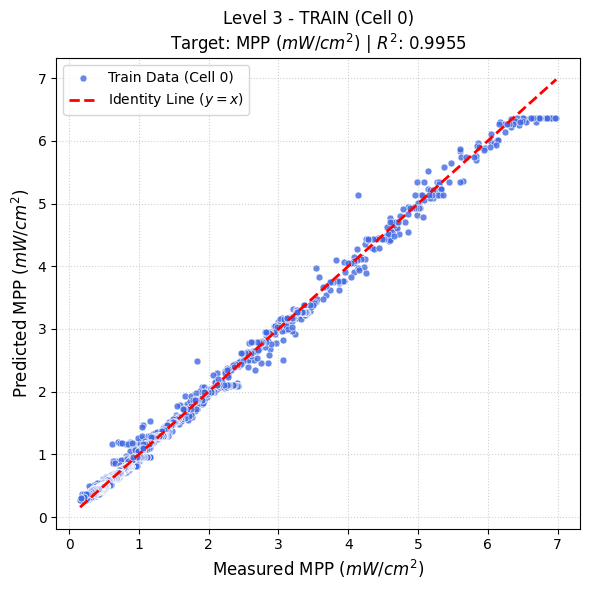


[VAL] --- Running GLOBAL Time Series Cross-Validation (Splits: 50) ---
 - Fold 01: MAE: 0.81 | RMSE: 0.96 | R2: 0.5049
 - Fold 02: MAE: 0.96 | RMSE: 0.99 | R2: -0.5476
 - Fold 03: MAE: 0.69 | RMSE: 0.74 | R2: -0.3830
 - Fold 04: MAE: 0.72 | RMSE: 0.77 | R2: -1.8953
 - Fold 05: MAE: 0.30 | RMSE: 0.32 | R2: -1.3113
 - Fold 06: MAE: 0.21 | RMSE: 0.23 | R2: -1.0160
 - Fold 07: MAE: 0.10 | RMSE: 0.11 | R2: 0.1850
 - Fold 08: MAE: 0.29 | RMSE: 0.29 | R2: -5.0874
 - Fold 09: MAE: 0.14 | RMSE: 0.14 | R2: -1.1807
 - Fold 10: MAE: 0.16 | RMSE: 0.16 | R2: -1.9900
 - Fold 11: MAE: 0.15 | RMSE: 0.16 | R2: -2.4006
 - Fold 12: MAE: 0.13 | RMSE: 0.13 | R2: -1.7958
 - Fold 13: MAE: 0.11 | RMSE: 0.11 | R2: -0.6716
 - Fold 14: MAE: 0.07 | RMSE: 0.08 | R2: -1.2502
 - Fold 15: MAE: 0.09 | RMSE: 0.10 | R2: -0.4485
 - Fold 16: MAE: 0.10 | RMSE: 0.11 | R2: -1.2960
 - Fold 17: MAE: 0.08 | RMSE: 0.09 | R2: -0.6069
 - Fold 18: MAE: 0.06 | RMSE: 0.07 | R2: 0.0705
 - Fold 19: MAE: 0.05 | RMSE: 0.06 | R2: 0.1897
 

In [ ]:
# =====================================================================
# EXECUTION BLOCK ("Burn-In" Diagnostic Phase)
# =====================================================================

features_diagnostico = [
    'G_accum_cont',
    'HA_accum_cont_g_m3',
    'Temp_accum_cont',
    'DeviceTemp',
    'G_mwcm2',
    'HA_g_m3'
]

print('\n[RUN] Training global model with continuous physical accumulations (14 Days)...')
df_res_m0, xgboost_m0, X_train_m0, X_valid_m0 = level_3_xgboost_dynamic(
    df_full=df_full,
    df_day=df_3,
    target_col='mpp_mwcm2',
    cell_id=0,
    isolate_target=True,
    train_day_split=15,
    cross_val=True,
    lags=False,
    accumulations=features_diagnostico
)

M0:


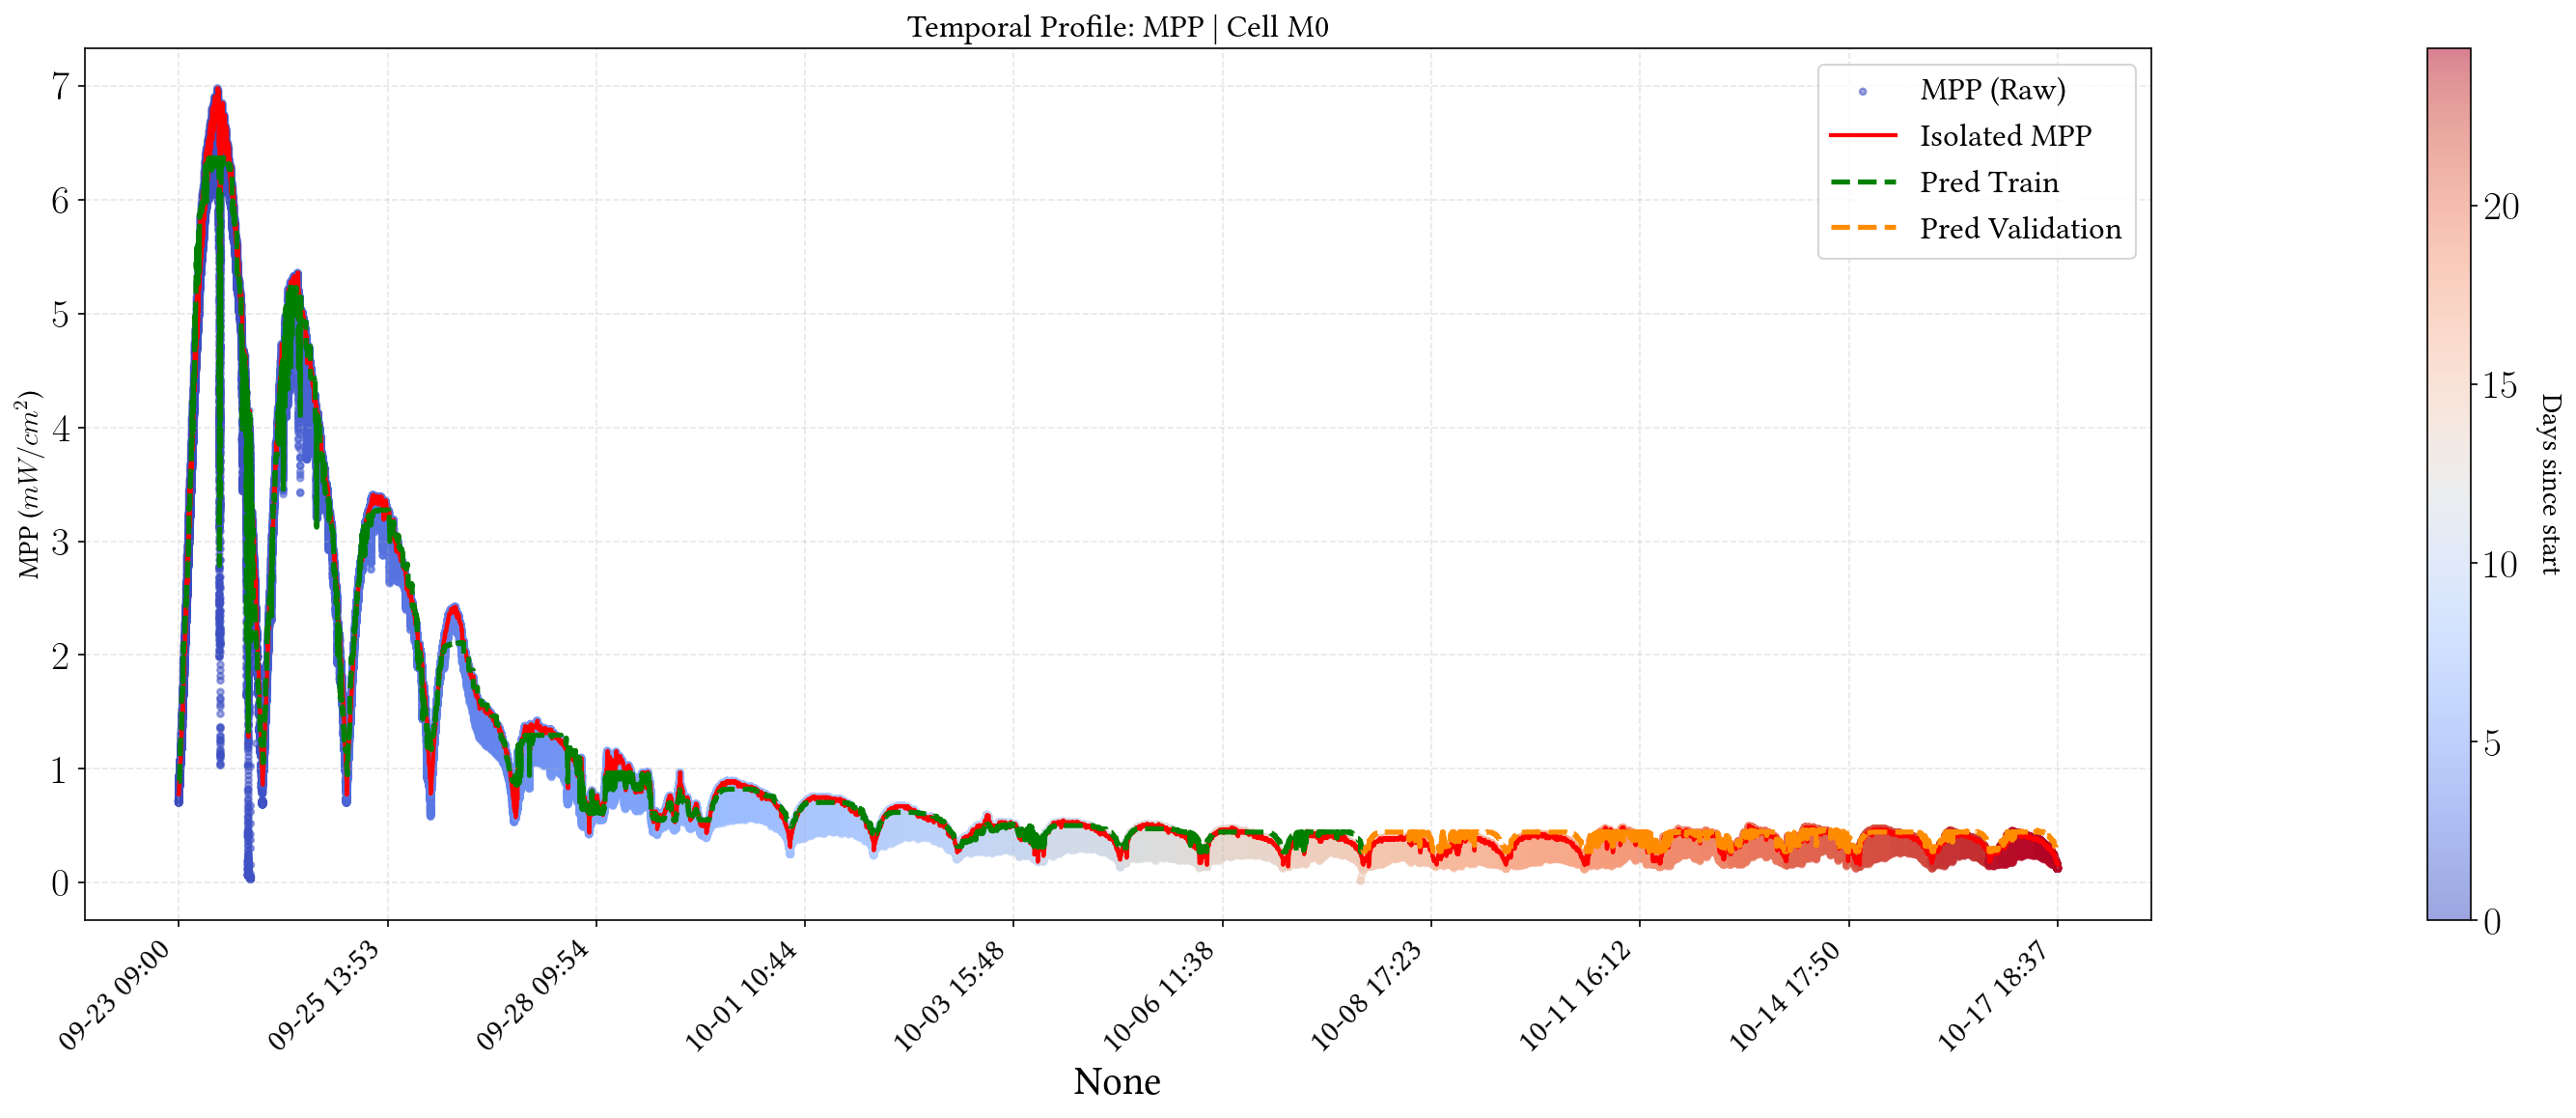

In [ ]:
print("M0:")
plot_profile(df=df_res_m0,  target_col='mpp_mwcm2',  cell_id=0, min_gci=0, min_G_mwcm2=0, min_power=0, isolated_target_line=True,
             start_date=pd.to_datetime('2025-09-23'),
             end_date=pd.to_datetime('2025-09-23') + pd.Timedelta(days=25),
             color=True, temp=False, feature=None, predicted=True, trend=False, Health=False)

**P12**

Starting Level 3 for cell_id=1. Modeling MPP ($mW/cm^2$)...

[INFO] Starting hyperparameter optimization...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'subsample': 0.85, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 20, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.6}
Best score: -0.549001357972154

[TRAIN] Cell 1 (mpp_mwcm2): MAE: 0.15 | RMSE: 0.22 | R2: 0.9477


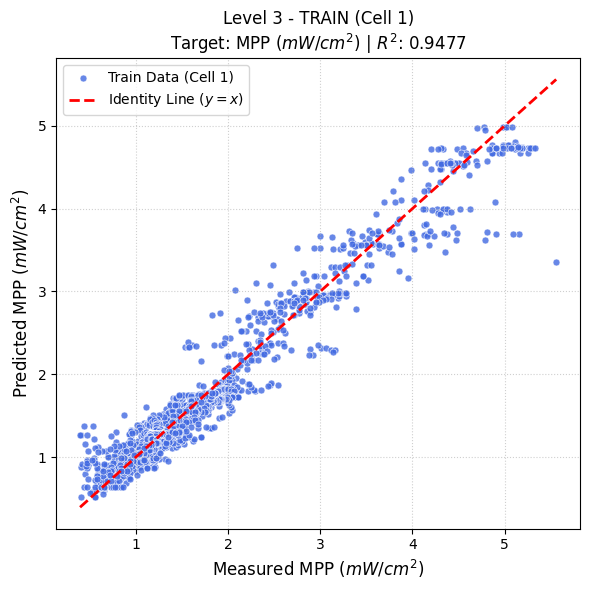


[VAL] --- Running GLOBAL Time Series Cross-Validation (Splits: 50) ---
 - Fold 01: MAE: 1.41 | RMSE: 1.70 | R2: -0.1904
 - Fold 02: MAE: 1.43 | RMSE: 1.49 | R2: -0.6536
 - Fold 03: MAE: 0.46 | RMSE: 0.60 | R2: 0.2577
 - Fold 04: MAE: 0.65 | RMSE: 0.71 | R2: -3.9868
 - Fold 05: MAE: 0.33 | RMSE: 0.36 | R2: 0.1699
 - Fold 06: MAE: 0.26 | RMSE: 0.29 | R2: -3.4819
 - Fold 07: MAE: 0.43 | RMSE: 0.48 | R2: -0.5016
 - Fold 08: MAE: 0.26 | RMSE: 0.31 | R2: -0.7271
 - Fold 09: MAE: 0.36 | RMSE: 0.40 | R2: -0.0020
 - Fold 10: MAE: 0.21 | RMSE: 0.31 | R2: 0.2799
 - Fold 11: MAE: 0.20 | RMSE: 0.24 | R2: 0.2315
 - Fold 12: MAE: 0.15 | RMSE: 0.18 | R2: 0.3494
 - Fold 13: MAE: 0.18 | RMSE: 0.19 | R2: 0.2155
 - Fold 14: MAE: 0.19 | RMSE: 0.24 | R2: 0.3149
 - Fold 15: MAE: 0.29 | RMSE: 0.31 | R2: -1.2118
 - Fold 16: MAE: 0.13 | RMSE: 0.17 | R2: 0.6666
 - Fold 17: MAE: 0.12 | RMSE: 0.15 | R2: 0.4544
 - Fold 18: MAE: 0.13 | RMSE: 0.15 | R2: 0.1228
 - Fold 19: MAE: 0.19 | RMSE: 0.20 | R2: -0.3493
 - Fold

In [ ]:
df_res_p12, xgboost_p12, X_train_p12, X_valid_p12 = level_3_xgboost_dynamic(
    df_full=df_full,
    df_day=df_3,
    target_col='mpp_mwcm2',
    cell_id=1,
    isolate_target=True,
    train_day_split=15,
    cross_val=True,
    lags=False,
    accumulations=features_diagnostico
)

P12:


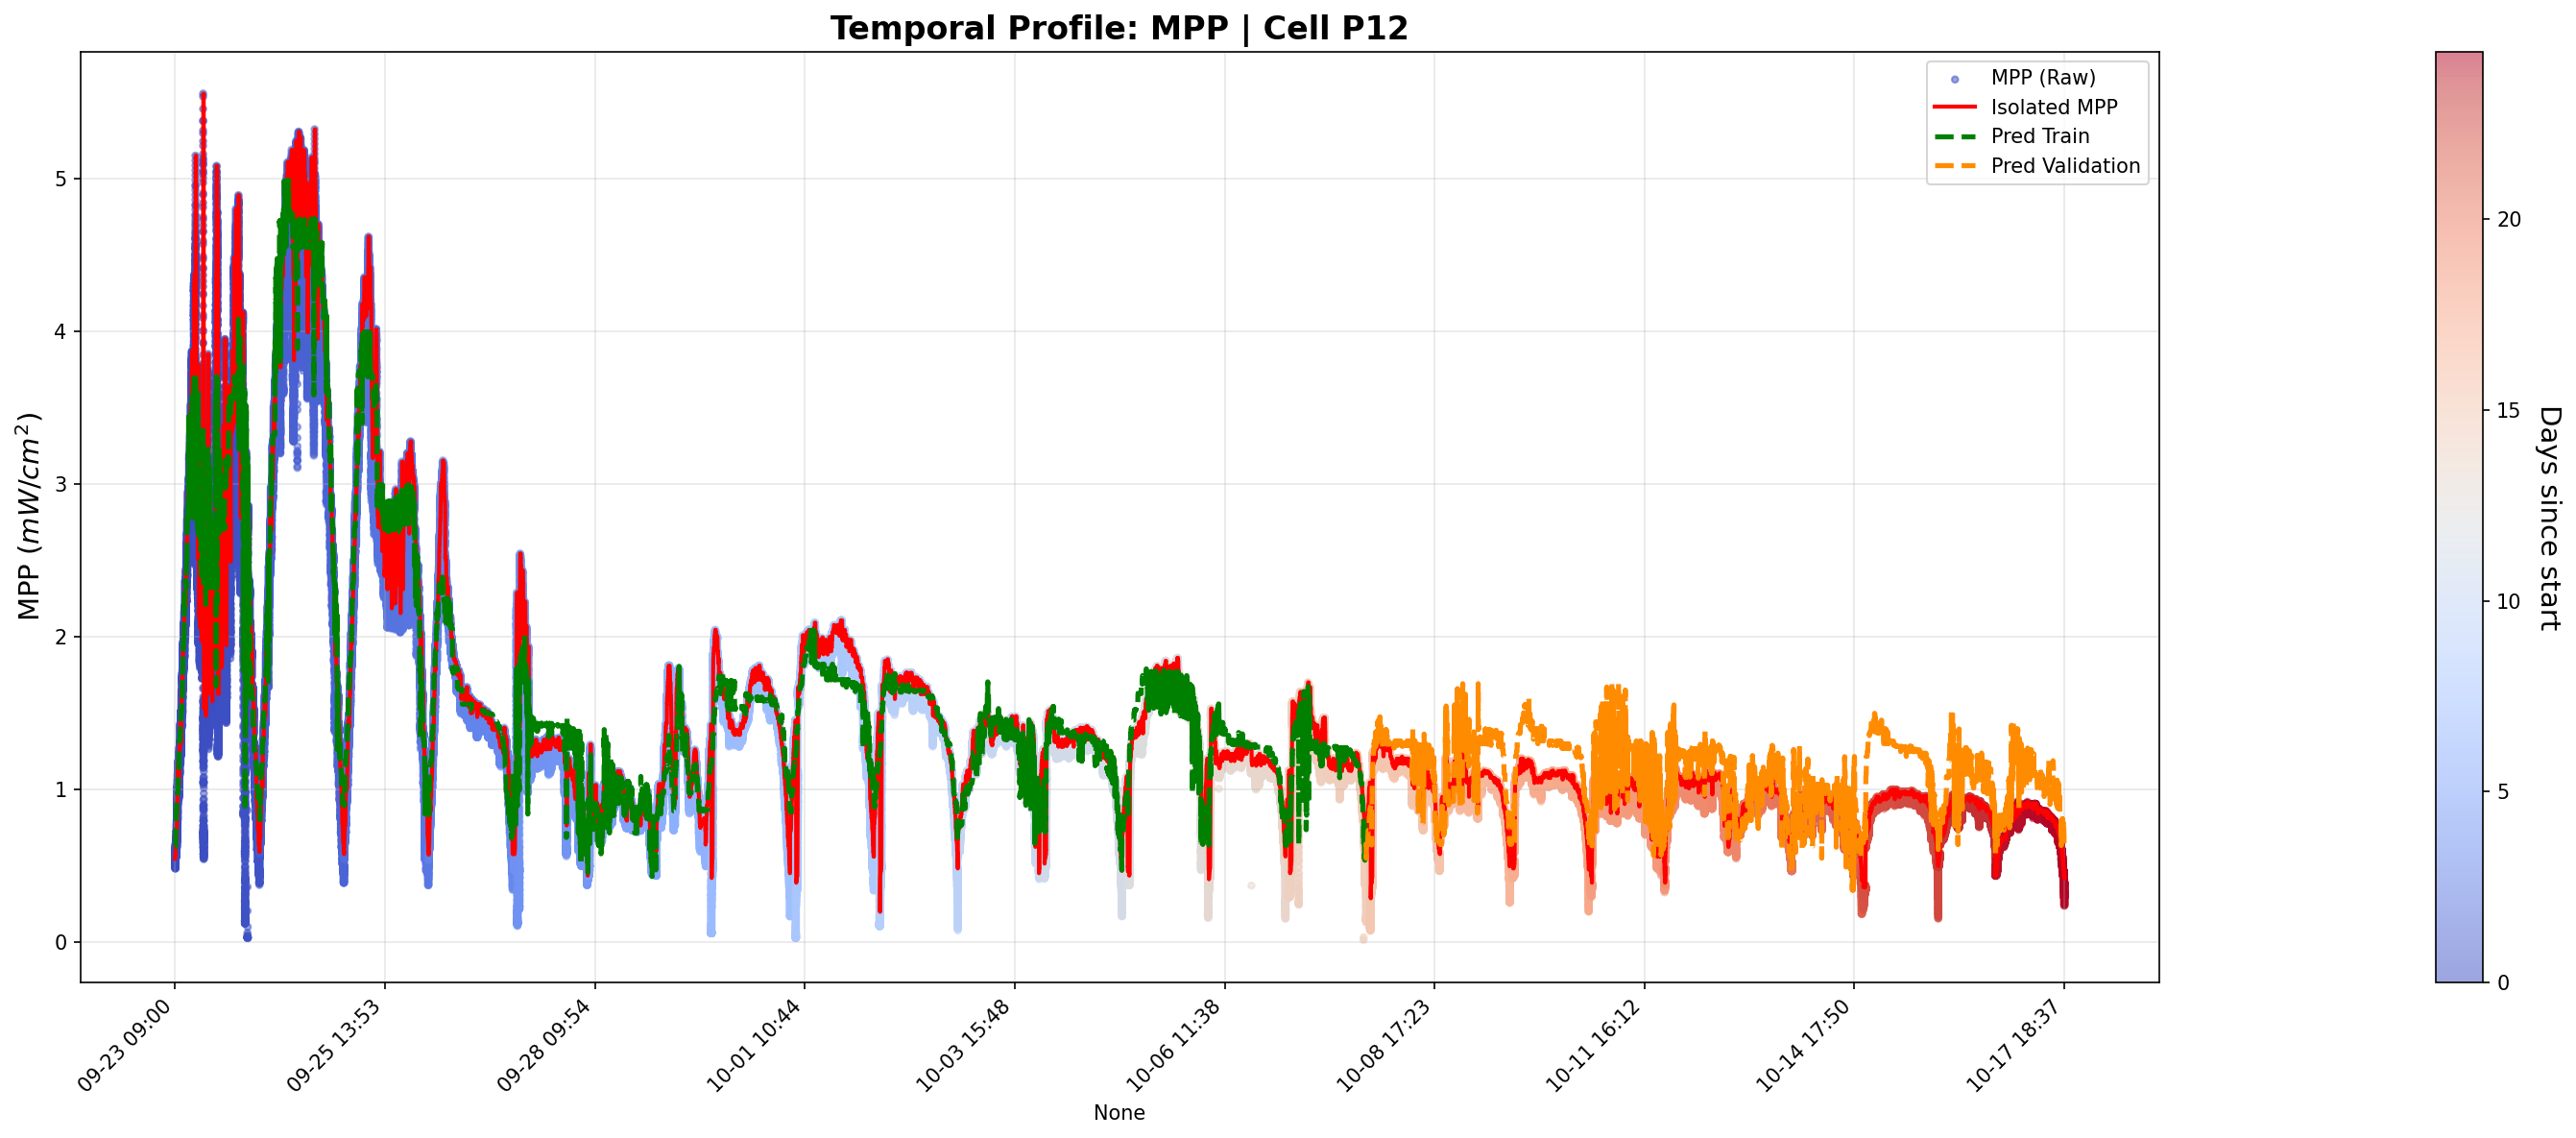

In [ ]:
print("P12:")
plot_profile(df=df_res_p12, target_col='mpp_mwcm2', cell_id=1, min_gci=0, min_G_mwcm2=0, min_power=0, isolated_target_line=True,
             start_date=pd.to_datetime('2025-09-23'),
             end_date=pd.to_datetime('2025-09-23') + pd.Timedelta(days=25),
             color=True, temp=False, feature=None, predicted=True, trend=False, Health=False)

**SHAP**

In [ ]:
!sudo apt-get update
!sudo apt-get install -y texlive-fonts-recommended texlive-fonts-extra cm-super dvipng

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.2 MB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,297 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,956 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,604 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,3


 GLOBAL SHAP ANALYSIS: CELL M0 
           Feature  Absolute_Impact  Contribution (%)  Avg_Negative  Peak_Negative (P5)
      G_accum_cont           0.6986           54.8367       -0.4745             -0.6925
HA_accum_cont_g_m3           0.2461           19.3195       -0.1660             -0.2472
           G_mwcm2           0.1992           15.6326       -0.2805             -0.4132
        DeviceTemp           0.0648            5.0849       -0.1166             -0.1479
   Temp_accum_cont           0.0630            4.9450       -0.0432             -0.0635
           HA_g_m3           0.0023            0.1813       -0.0046             -0.0054

 GLOBAL SHAP ANALYSIS: CELL P12 
           Feature  Absolute_Impact  Contribution (%)  Avg_Negative  Peak_Negative (P5)
           G_mwcm2           0.3209           33.5903       -0.4841             -0.8296
      G_accum_cont           0.2106           22.0462       -0.1370             -0.2539
HA_accum_cont_g_m3           0.1548           16.2061

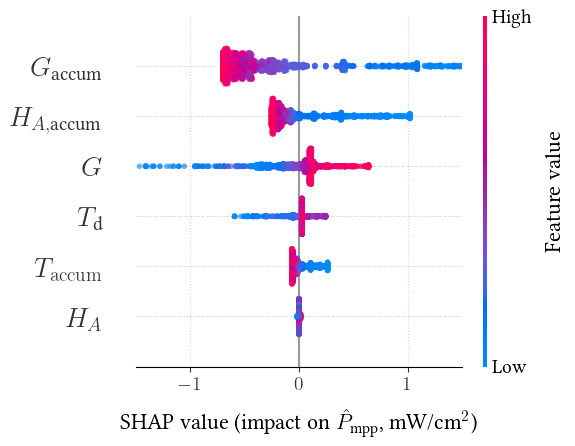

Plot saved as: shap_analysis_P12.pdf


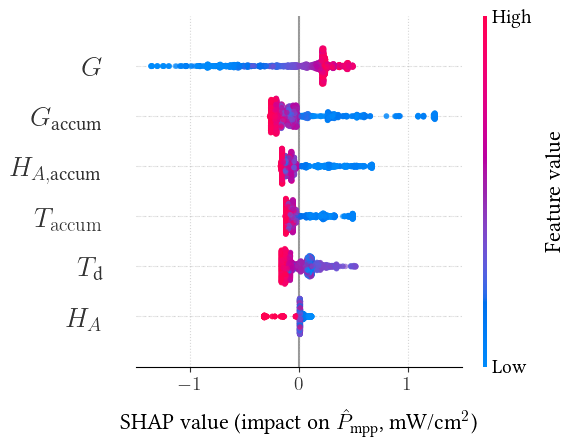

In [ ]:
plt.style.use('default')
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'text.latex.preamble': r'\usepackage{libertine} \usepackage[T1]{fontenc} \usepackage{amsmath} \usepackage{bm}',

    'font.size': 16,               # General base size
    'axes.labelsize': 20,          # Axis titles (X and Y)
    'xtick.labelsize': 16,         # X scale numbers
    'ytick.labelsize': 20,         # IMPORTANT: Very large for variables (G_accum, etc.)
    'legend.fontsize': 16,         # Legend text
    'axes.titlesize': 20,          # Plot titles
    'figure.titlesize': 22,

    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.autolayout': True      # Prevents long labels from being cut off when saving
})

# ==============================================================================
# 0. LABEL CONFIGURATION AND MAPPINGS
# ==============================================================================
latex_labels_map = {
    'G_mwcm2': r'$G$',
    'DeviceTemp': r'$T_{\text{d}}$',  # Adjusted to T_d to maintain consistency with your text
    'HA_g_m3': r'$H_A$',
    'G_accum_cont': r'$G_{\text{accum}}$',
    'Temp_accum_cont': r'$T_{\mathrm{accum}}$',
    'HA_accum_cont_g_m3': r'$H_{A, \text{accum}}$',
    'hour_sin': r'$\sin(2\pi h/24)$',
    'hour_cos': r'$\cos(2\pi h/24)$'
}

# ==============================================================================
# 1. ANALYTICAL FUNCTIONS (Impact and Threshold Calculation)
# ==============================================================================
def extract_shap_insights(shap_vals: np.ndarray, X_data: pd.DataFrame, cell_name: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Extracts global importance and builds the Master DataFrame of impacts."""
    mean_abs_impact = np.abs(shap_vals).mean(axis=0)
    total_impact = mean_abs_impact.sum()
    contrib_pct = (mean_abs_impact / total_impact) * 100 if total_impact > 0 else 0

    df_summary = pd.DataFrame({
        'Feature': X_data.columns,
        'Absolute_Impact': mean_abs_impact,
        'Contribution (%)': contrib_pct,
        'Avg_Negative': [vals[vals < 0].mean() if (vals < 0).any() else 0.0 for vals in shap_vals.T],
        'Peak_Negative (P5)': [np.percentile(vals, 5) for vals in shap_vals.T]
    }).sort_values(by='Absolute_Impact', ascending=False).reset_index(drop=True)

    df_shap = pd.DataFrame(shap_vals, columns=[f"{col}_SHAP" for col in X_data.columns], index=X_data.index)
    df_master = pd.concat([X_data, df_shap], axis=1)

    print(f"\n{'='*80}\n GLOBAL SHAP ANALYSIS: CELL {cell_name} \n{'='*80}")
    print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    return df_summary, df_master

def analyze_thresholds(df_master, cell_name):
    """Analysis of critical points and chronological degradation."""
    print(f"\n--- Inflection Points and Thresholds: {cell_name} ---")
    features_to_check = ['HA_accum_cont_g_m3', 'G_accum_cont', 'DeviceTemp']

    for feat in features_to_check:
        if feat in df_master.columns:
            shap_col = f"{feat}_SHAP"

            # 1. Critical Threshold (Top 20% of physical stress)
            p80 = df_master[feat].quantile(0.80)
            avg_p80_impact = df_master[df_master[feat] > p80][shap_col].mean()
            print(f"[{feat:18}] Impact at P80 (>{p80:8.2f}): {avg_p80_impact:8.4f} mW/cm²")

            # 2. CORRECTED LOGIC: Real Degradation Onset
            max_shap = df_master[shap_col].max()
            min_shap = df_master[shap_col].min()
            shap_range = max_shap - min_shap

            if shap_range > 0.01:
                drop_threshold = max_shap - (0.05 * shap_range)
                degrad = df_master[df_master[shap_col] < drop_threshold].sort_index()

                if not degrad.empty:
                    date_str = degrad.index[0].strftime('%Y-%m-%d %H:%M')
                    val_at_onset = degrad.iloc[0][feat]
                    print(f"   ➔ Real Degradation Onset (5% drop from peak): {date_str} (Stress value: {val_at_onset:.2f})")
            else:
                print(f"   ➔ No physical impact detected (Irrelevant or perfectly resistant variable).")

# ==============================================================================
# 2. COMPARATIVE VISUALIZATION FUNCTION
# ==============================================================================
def plot_comparative_shap(shap_v_m0, X_v_m0, shap_v_p12, X_v_p12, x_limit=1.5):
    data_to_plot = [
        (shap_v_m0, X_v_m0, "M0", "Hybrid"),
        (shap_v_p12, X_v_p12, "P12", "MAPI")
    ]

    common_xlim = (-x_limit, x_limit)

    for shap_vals, X_data, cell_id, chemistry in data_to_plot:
        latex_names = [latex_labels_map.get(col, col) for col in X_data.columns]

        # Generate SHAP with a MUCH SMALLER base size.
        # This way LaTeX will not shrink the image and the fonts will remain large.
        shap.summary_plot(
            shap_vals,
            X_data,
            feature_names=latex_names,
            show=False,
            plot_size=(5.5, 4.5),
            alpha=0.6
        )

        # Retrieve the axes that SHAP just created
        fig = plt.gcf()
        ax = plt.gca()

        # --- FONT ADJUSTMENTS ---
        # Since the image is small, these sizes (16-20) will look HUGE
        ax.set_xlabel(r'SHAP value (impact on $\hat{P}_{\text{mpp}}$, mW/cm$^2$)',
                      fontsize=16, labelpad=10)
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=20) # Variables (G_accum, etc.)

        # --- COLOR BAR ADJUSTMENT ---
        if len(fig.axes) > 1:
            cb_ax = fig.axes[-1]
            cb_ax.set_ylabel("Feature value", fontsize=16, labelpad=10)

            # Explicitly force the size of the "Low" and "High" texts
            cb_ax.tick_params(labelsize=14)
            cb_ax.set_yticklabels(['Low', 'High'], fontsize=14)

        ax.set_xlim(common_xlim)
        ax.grid(True, axis='x', linestyle=':', alpha=0.5)

        # Save (we use bbox_inches='tight' so nothing gets cut off)
        filename = f"shap_analysis_{cell_id}.pdf"
        plt.savefig(filename, bbox_inches='tight', dpi=600)
        print(f"Plot saved as: {filename}")

        # Display the plot in the console / notebook
        plt.show()

        plt.close()

# ==============================================================================
# 3. PIPELINE EXECUTION
# ==============================================================================

# 1. Generate Explainers and SHAP Values (using X_train as reference)
explainer_m0 = shap.TreeExplainer(xgboost_m0)
shap_values_m0 = explainer_m0.shap_values(X_train_m0)

explainer_p12 = shap.TreeExplainer(xgboost_p12)
shap_values_p12 = explainer_p12.shap_values(X_train_p12)

# 2. Extract quantitative insights
summary_m0, master_m0 = extract_shap_insights(shap_values_m0, X_train_m0, "M0")
summary_p12, master_p12 = extract_shap_insights(shap_values_p12, X_train_p12, "P12")

# 3. Critical Thresholds Analysis
analyze_thresholds(master_m0, "M0")
analyze_thresholds(master_p12, "P12")

# 4. Final Comparative Visualization
plot_comparative_shap(shap_values_m0, X_train_m0, shap_values_p12, X_train_p12, x_limit=1.5)